# FVCA

In [3]:
from trustutils import run

run.introduction("Yannick Gorsse")

run.TRUST_parameters()

## Introduction 
 Validation made by : Yannick Gorsse



 Report generated 15/12/2025

### TRUST parameters 
 * Version TRUST: 1.9.7
 * Binary used: /Volumes/codes/tnk/TRUST_NK_opt (built in directory /Volumes/codes/trust/Validation/Rapports_automatiques/Verification/Verification_codage/fvca/build)

### Description: 



In [ ]:
from trustutils import run
from string import Template
import os, sys
run.useMEDCoupling()
import medcoupling as mc
run.reset()

seq = True
nb_meshes_max = 4 # mettre a 10 si on veut faire tous les maillages

run.reset()
m2d = {
    # 2D meshes
    "Cartesian":      (["PolyVEF_P0"], 7),
    "Triangles":      (["PolyVEF_P0"], 6),
    "Locally_Refined":(["PolyVEF_P0"], 7),
    "Quadrangles":    (["PolyVEF_P0"], 7),
    "Kershaw2D":      (["PolyVEF_P0"], 6),
    "Polygons":       (["PolyVEF_P0"], 6),
}
m3d = {
    # 3D meshes
    "Tetra":          (["PolyVEF_P0"], 7),
    "Hexa":           (["PolyVEF_P0"], 5), # TODO : ajouter VDF, mais veut pas unpolyze...
    # "Prism":          (["PolyVEF_P0"], 4),
    # "Kershaw":        (["PolyVEF_P0"], 4),
    "CheckerBoard":   (["PolyVEF_P0"], 5),
    # "PrismHexa":      (["PolyVEF_P0"], 4),
    "LocRaf":         (["PolyVEF_P0"], 5),
    # "Random":         (["PolyMAC_P0"], 4),
    # "Voronoi":        (["PolyMAC_P0"], 5),
}
mxd = { 2 : m2d, 3 : m3d }
tests = {
    # "bercovier_engelman" : 2,
    "taylor_green_3d" : 3,
    # "navier_stokes_2d" : 2,
    "navier_stokes_3d" : 3
}

meshes_dir = os.environ["TRUST_ROOT"] + "/Validation/Rapports_automatiques/Verification/PolyMAC/share/meshes"

# Trigger the copy of the src directory into the build directory:
run.initBuildDirectory()
origin, build_dir = os.getcwd(), run.BUILD_DIRECTORY
os.chdir(build_dir)
list_dis = []
for test, dim in tests.items():
    for m, (dis, ns) in mxd[dim].items():
        for d in dis:
            for n in range(1, min(ns, nb_meshes_max) + 1):
                os.system(f"mkdir -p {test}/{m}/{d}/{n}")
                with open(f"{test}.data", "r") as file: filedata = Template(file.read())
                result = filedata.substitute({"dis" : d, "solv" : "solveur_U_P { solveur petsc cholesky { cli { -mat_mumps_icntl_23 10000 } } }" if d.startswith("Poly") else "implicite { solveur petsc cholesky { cli { -mat_mumps_icntl_23 10000 } } }" })
                with open(f"{test}/{m}/{d}/{n}/jdd.data", "w") as file: file.write(result)
                if not d.startswith("Poly"):
                    os.system(f"gunzip -c {meshes_dir}/{m}/jdd_{n}/mesh.med.gz >{test}/{m}/{d}/{n}/mesh.med")
                    meshname = f"{test}/{m}/{d}/{n}/mesh.med"
                    mfum = mc.MEDFileUMesh(meshname)
                    mfum.getMeshAtLevel(0).unPolyze()
                    mfum.write(f"{test}/{m}/{d}/{n}/mesh.med", 2)
                else: os.system(f"gunzip -c {meshes_dir}/{m}/jdd_{n}/mesh.med.gz >{test}/{m}/{d}/{n}/mesh.med")
                np = 1 if seq else min(int(os.environ["TRUST_NB_PROCS"]), 8 if n < 2 else 128)
                os.system(f"cp post_run {test}/{m}/{d}/{n}/")
                if not seq: os.system(f"cd {test}/{m}/{d}/{n}/; make_PAR.data jdd {np} >/dev/null 2>&1")
                #echo $mesh/jdd_${n}/cas.data >> ll
                cas = run.addCase(f"{test}/{m}/{d}/{n}", f"{'' if seq else 'PAR_'}jdd.data", np)
                # PolyMAC discretization is portability-sensitive #
                # if d=="PolyMAC":
                #     cas.substitute("_lance_test_","# lance_test 8 ecarts #")
                # else:
                # cas.substitute("_lance_test_","")
                list_dis.append(f"{test}/{m}/{d}")

with open("extract_convergence", "r") as file: fileconv = Template(file.read())
result = fileconv.safe_substitute(list_dis=" ".join(sorted(list(set(list(list_dis))))))
with open("extract_convergence", "w") as file: file.write(result)
os.chdir(origin)

# run.printCases()
run.runCases()
run.executeScript("extract_convergence")

Running **with Sserver**...
  => A total of 32 cases were (successfully) run in 192.5s.


In [5]:
from trustutils import plot
import matplotlib.colors as mcolors
import pandas as pd
from matplotlib.lines import Line2D
c = list(mcolors.TABLEAU_COLORS.keys())
linestyle = {"PolyMAC_P0P1NC": ("-", "v"), "PolyMAC_P0" : ("-", "^"), "PolyVEF_P0" : ("-", "2"), "PolyVEF_P0P1NC" : ("-", "1"), "PolyVEF_P0P1" : ("-", "<"), "PolyMAC" : ("-", "o"), "VDF" : ("-", "s"), "VEFPreP1b" : ("-", "s"), }

lines_and_markers = {test : [Line2D([0], [0], color=c[k]) for k, _ in enumerate(mxd[dim].items())] for test, dim in tests.items()}
for test in tests.keys(): lines_and_markers[test] += [Line2D([0], [0], color="black", marker=m, linestyle=s) for _, (s, m) in linestyle.items()]
names_in_legend = {test : list(mxd[dim].keys()) for test, dim in tests.items()}
for test in tests.keys(): names_in_legend[test] += list(linestyle.keys())

def make_custom_legend(graph, test):
    try:
        for ax in graph.axs:
            ax.legend(lines_and_markers[test], names_in_legend[test], loc='upper center', ncol=4, bbox_to_anchor=(0.5, -0.1))
    except:
        graph.subplot.legend(lines_and_markers[test], names_in_legend[test], loc='upper center', ncol=4, bbox_to_anchor=(0.5, -0.1))


## Ordres de convergence

discrétisation PolyVEF_P0          
var                     p         u
Tetra            0.868942  1.106812
Hexa             1.184662  2.093409
CheckerBoard     1.980458  1.611742
LocRaf           1.812987  2.091285

taylor_green_3d
\begin{tabular}{lrr}
\toprule
discrétisation & \multicolumn{2}{c}{PolyVEF_P0} \\
var & p & u \\
\midrule
Tetra & 0.87 & 1.11 \\
Hexa & 1.18 & 2.09 \\
CheckerBoard & 1.98 & 1.61 \\
LocRaf & 1.81 & 2.09 \\
\bottomrule
\end{tabular}



discrétisation PolyVEF_P0          
var                     p         u
Tetra            1.080437  1.030079
Hexa             1.556675  2.192400
CheckerBoard     1.128110  1.529431
LocRaf           1.488364  1.667276

navier_stokes_3d
\begin{tabular}{lrr}
\toprule
discrétisation & \multicolumn{2}{c}{PolyVEF_P0} \\
var & p & u \\
\midrule
Tetra & 1.08 & 1.03 \\
Hexa & 1.56 & 2.19 \\
CheckerBoard & 1.13 & 1.53 \\
LocRaf & 1.49 & 1.67 \\
\bottomrule
\end{tabular}



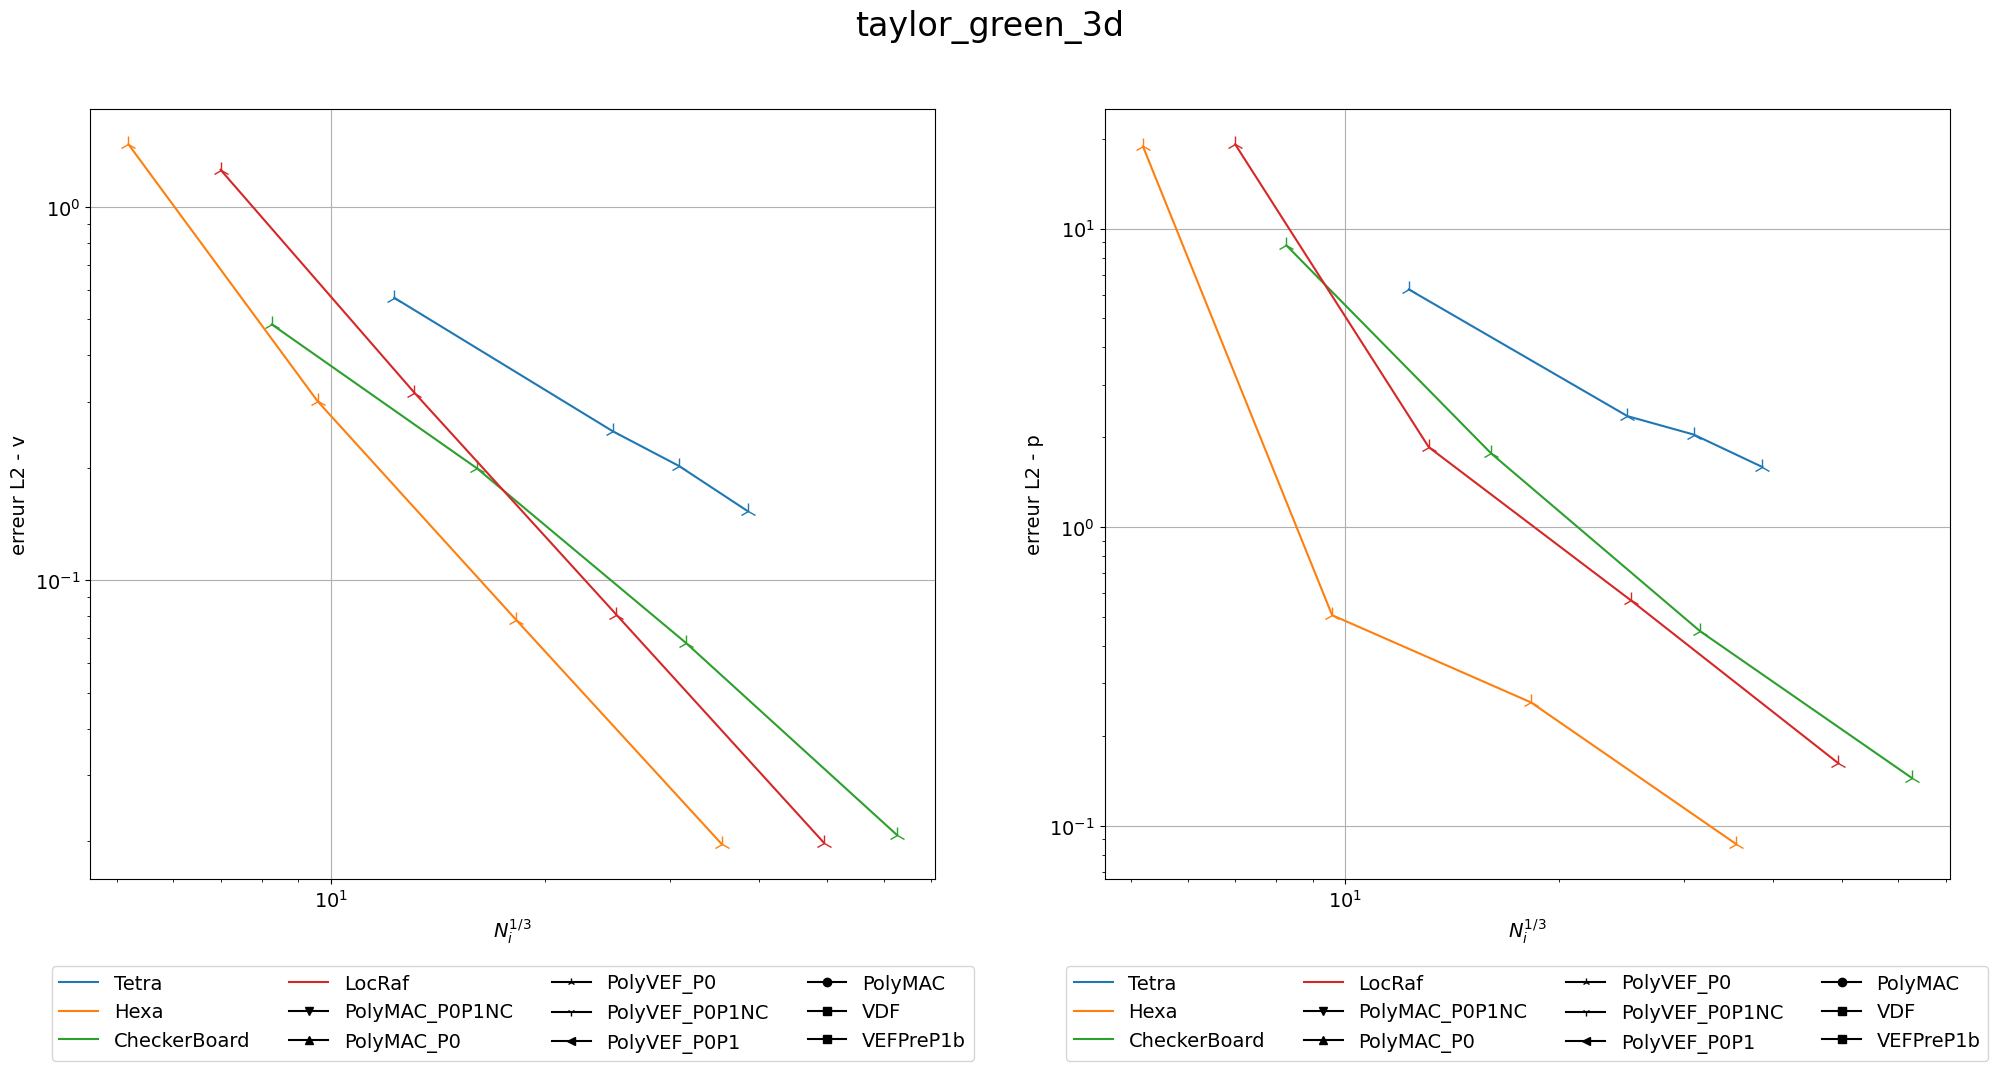

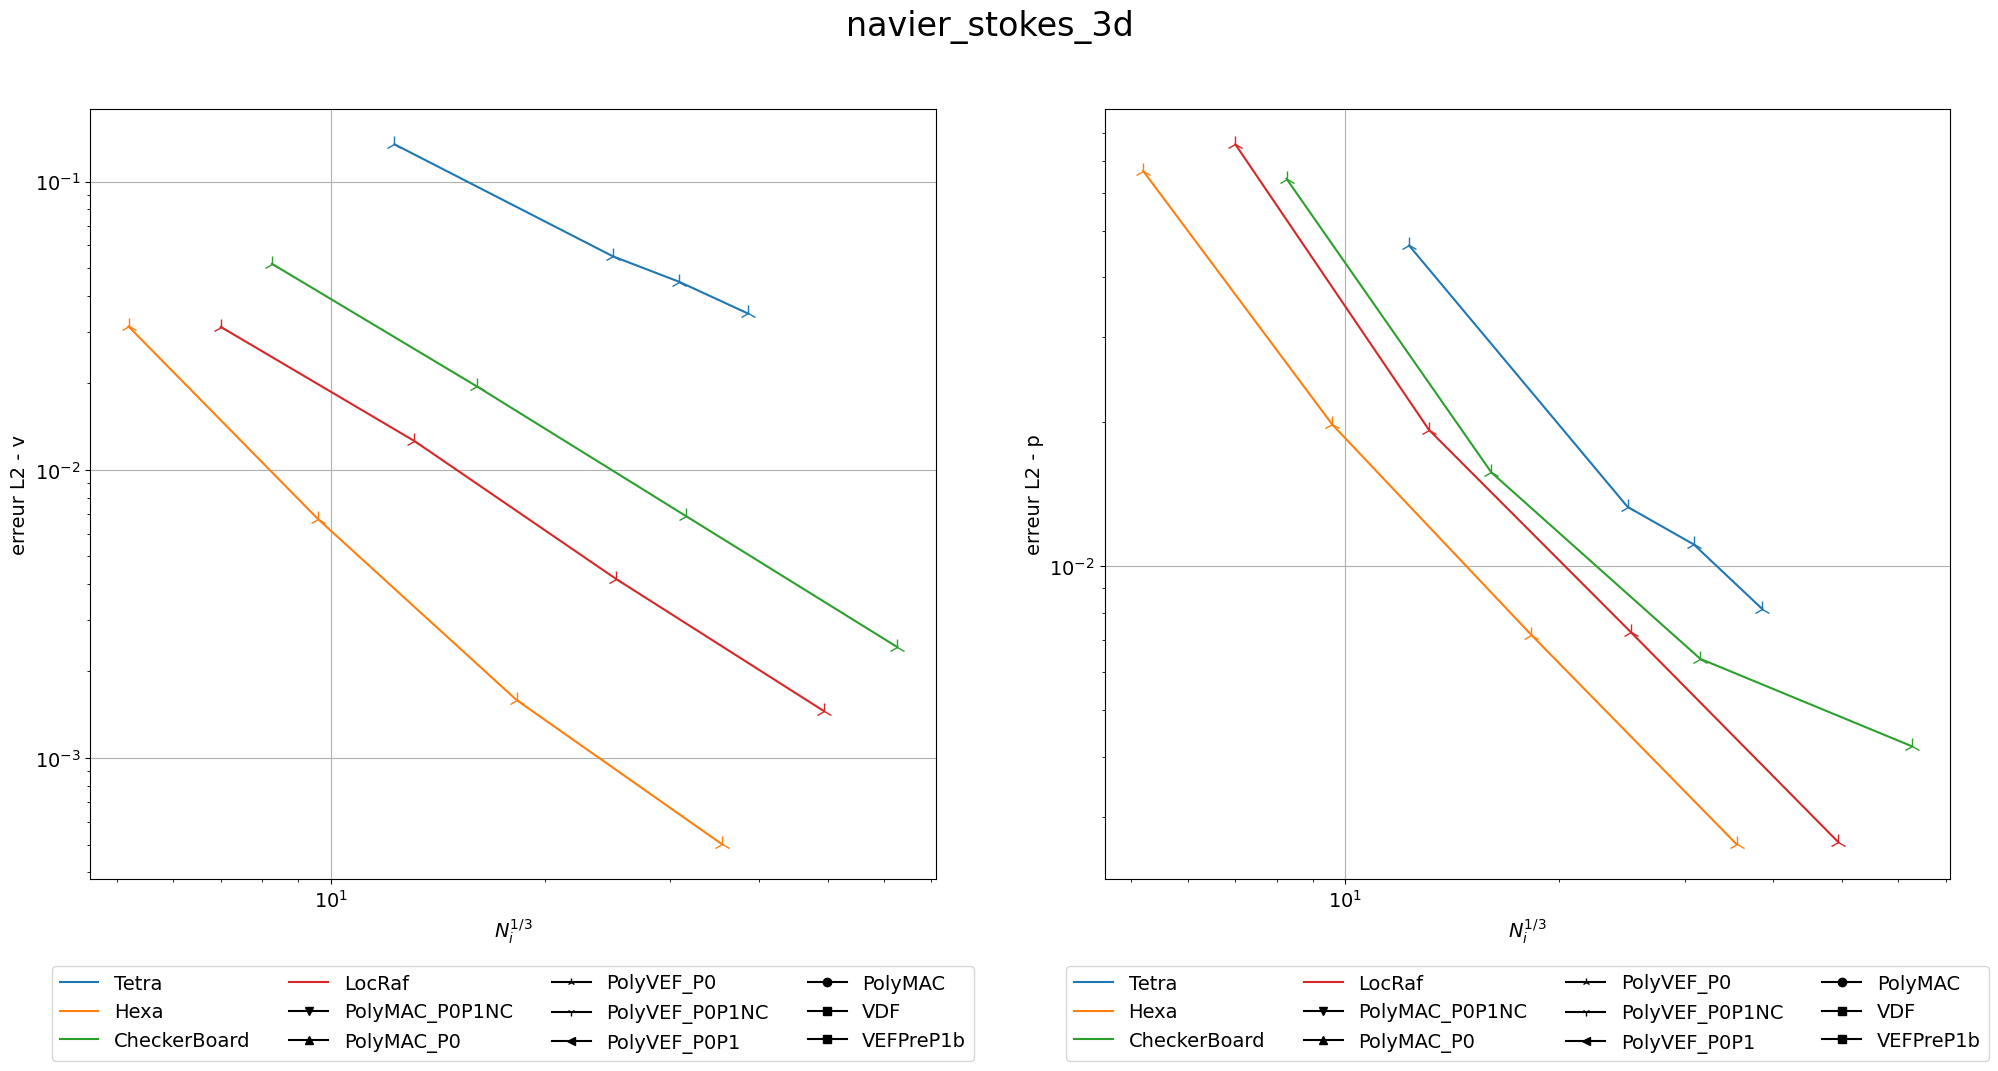

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

def func(x, a, b):
    return a * x ** b

var_map = {"v": "u", "p": "p"}  # pour tes colonnes

for test, dim in tests.items():
    orders = {}
    a = plot.Graph(f"{test}", nY=2)
    for k, (m, (dis, ns)) in enumerate(mxd[dim].items()):
        for d in dis:
            for i, var in enumerate(["v", "p"]):
                a.addPlot(i)
                x_ = plot.loadText(f"{test}/{m}/{d}/conv_glob_{var}")
                x, y = (np.power(x_[0], 1.0 / dim)).tolist(), x_[1].tolist()

                try:
                    (_, b), _ = curve_fit(func, x[1:], y[1:])
                except Exception:
                    b = np.nan

                orders.setdefault(m, {})[(d, var_map[var])] = -b

                a.add(x, y, label=None, color=c[k],
                      linestyle=linestyle[d][0], marker=linestyle[d][1], markersize=12)
                a.label(f"$N_i^{{1/{dim}}}$", f"erreur L2 - {var}")
                a.scale(xscale='log', yscale='log')

    make_custom_legend(a, test)

    # DataFrame: lignes = maillages, colonnes = (discrétisation, u/p)
    df_orders = pd.DataFrame.from_dict(orders, orient="index")
    df_orders.columns = pd.MultiIndex.from_tuples(df_orders.columns, names=["discrétisation", "var"])
    df_orders = df_orders.sort_index(axis=1, level=[0, 1])

    display(df_orders)

    # si tu veux un format fixe à 2 décimales
    print(test)
    print(df_orders.to_latex(float_format="%.2f", multicolumn=True, multicolumn_format="c"))

## Temps de calcul

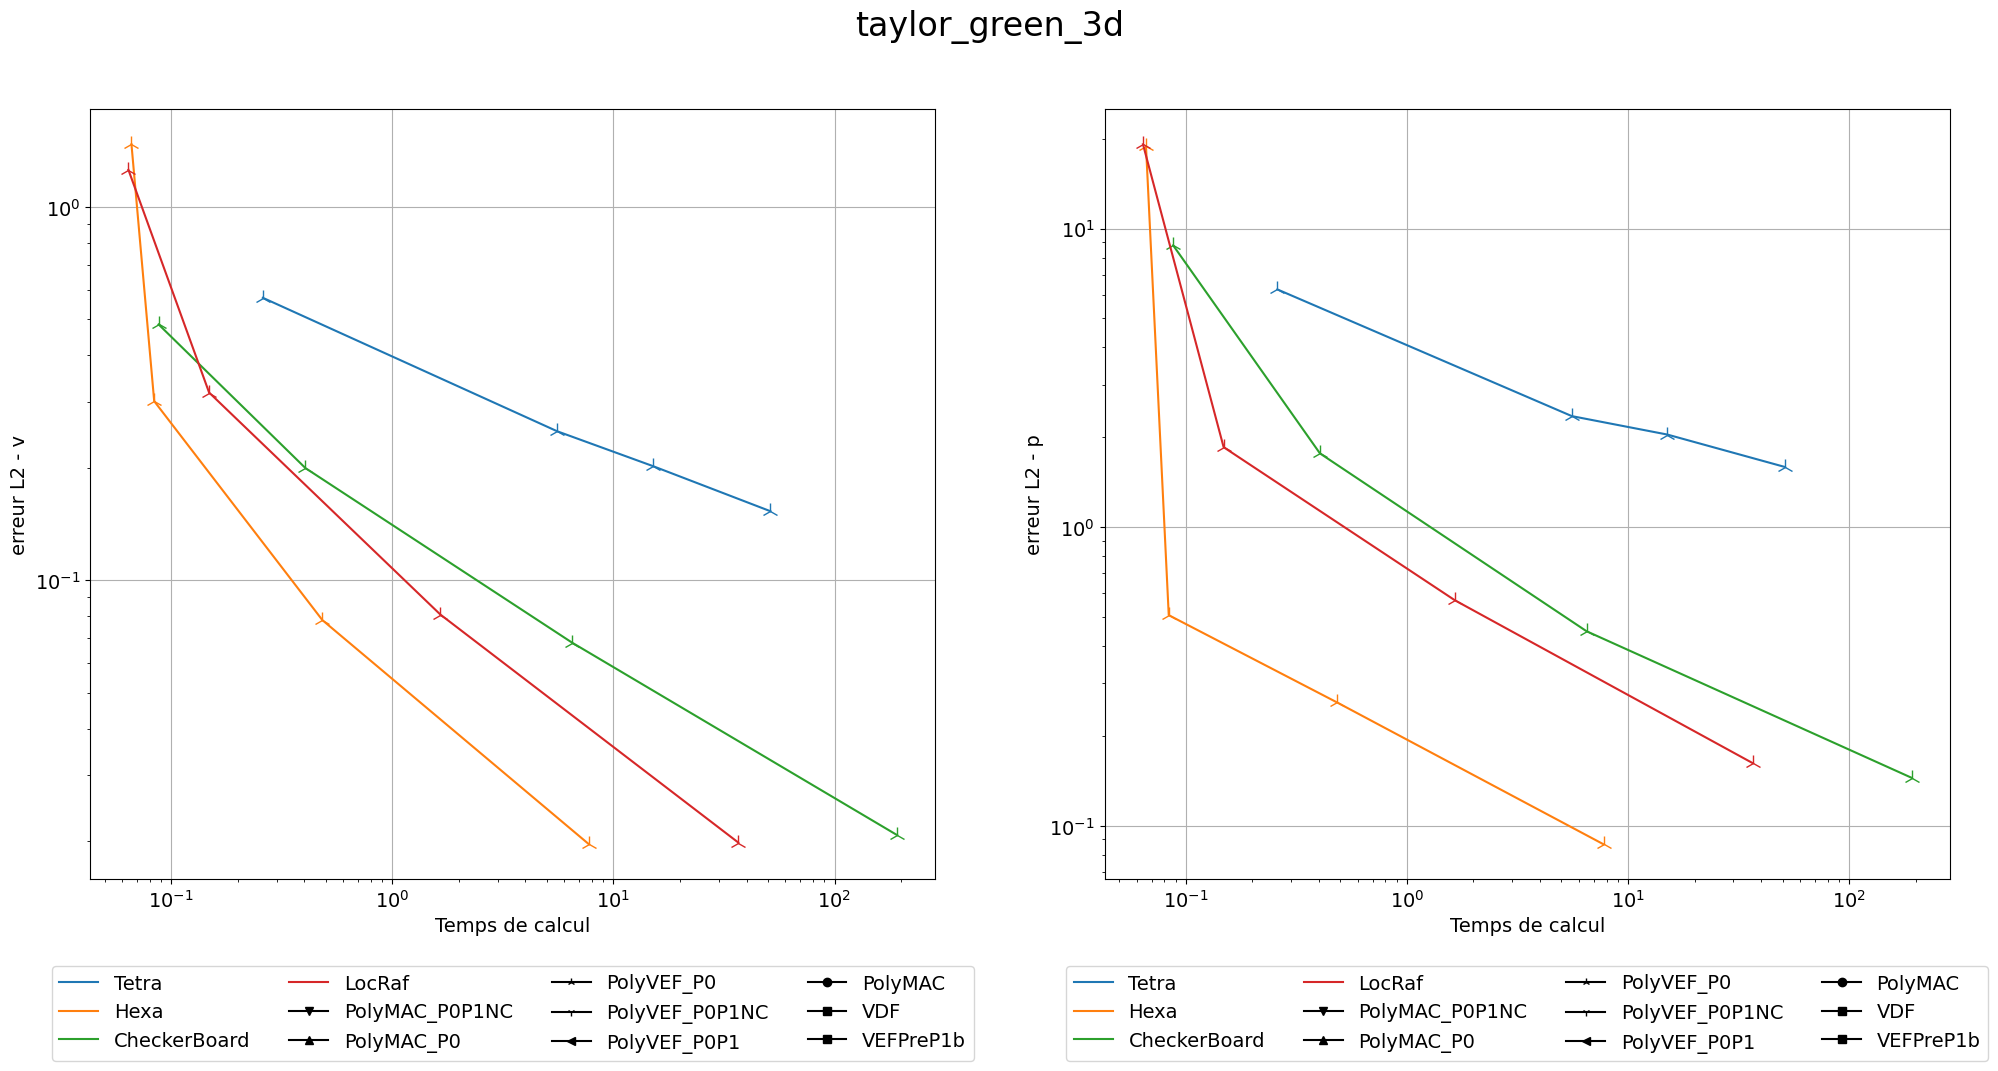

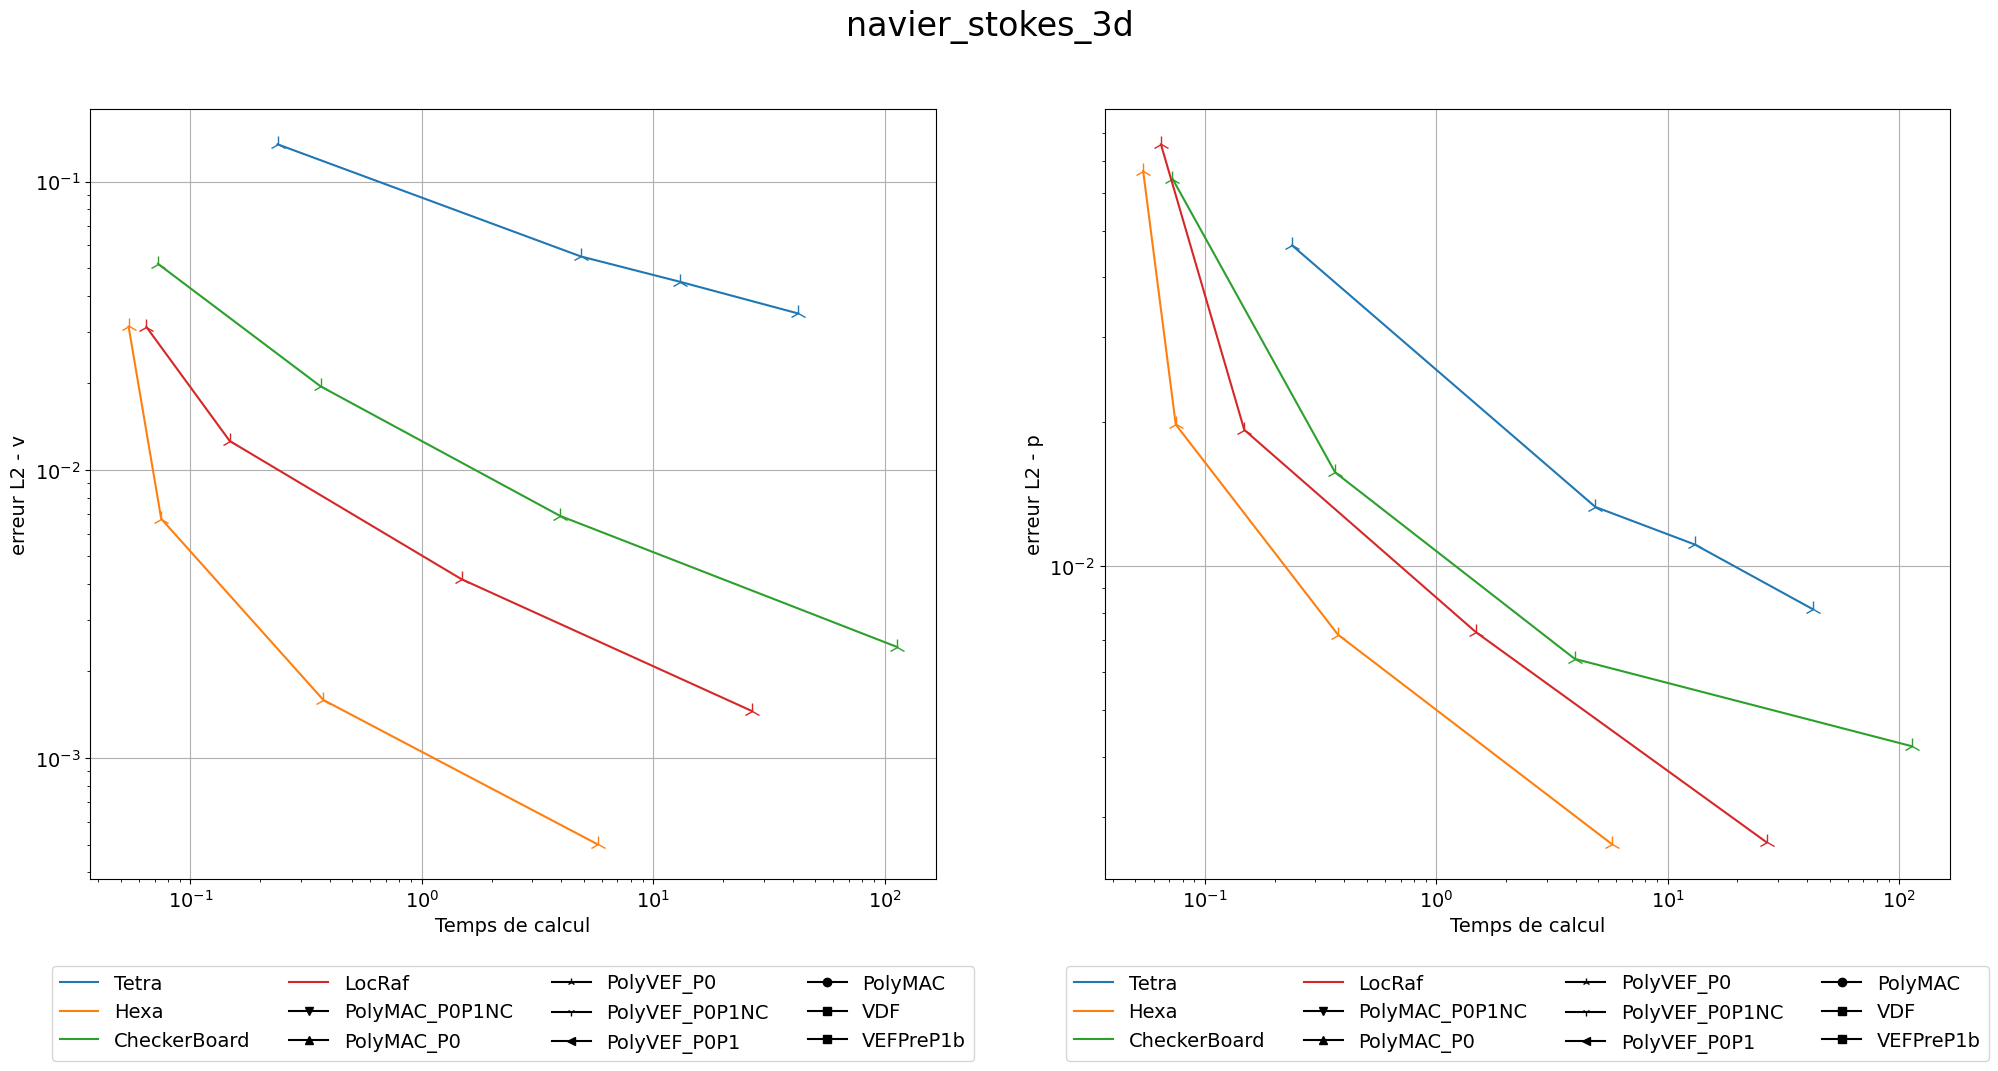

In [7]:
for test, dim in tests.items():
    a = plot.Graph(f"{test}", nY=2)
    for k, (m, (dis, _)) in enumerate(mxd[dim].items()):
        for d in dis:
            for i, var in enumerate(["v", "p"]):
                a.addPlot(i)
                x_ = plot.loadText(f"{test}/{m}/{d}/conv_glob_{var}")
                x, y = x_[2].tolist(), x_[1].tolist()
                a.add(x, y, label=None, color=c[k], linestyle=linestyle[d][0], marker=linestyle[d][1], markersize=12)

                a.label(f"Temps de calcul", f"erreur L2 - {var}")
                a.scale(xscale='log',yscale='log')
    make_custom_legend(a, test)
